# House Price Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/house_price_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1460, 268)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,0,1,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,0,1,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,0,1,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,0,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,0,1,0,0,0,1,0


## 2. Train / Test Split & Scaling

In [3]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 267
Target stats:
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64
Train: (1168, 267) Test: (292, 267)


## 3. Train 7 Regressors

In [4]:
results = []
models = {}


  Linear Regression
  MAE   : 876364231634836.8750
  RMSE  : 10273859652782368.0000
  R2    : -13761108630056256667648.0000
  MAPE  : 4764415929.5648


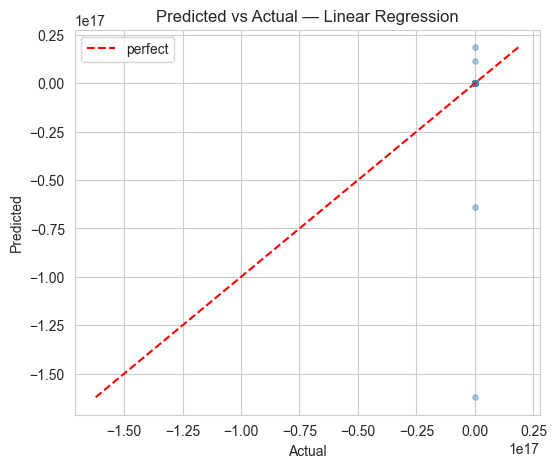

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 19588.4880
  RMSE  : 35807.3724
  R2    : 0.8328
  MAPE  : 0.1191


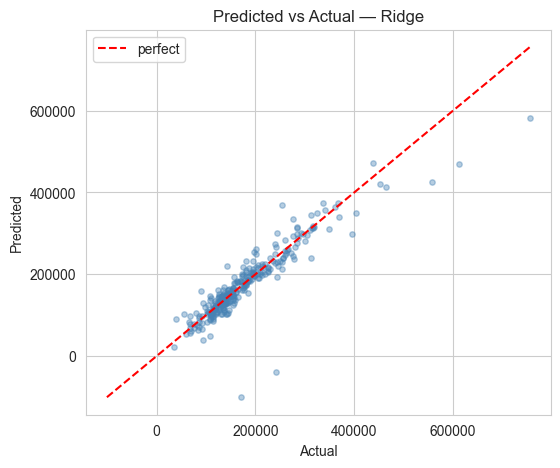

In [6]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 22336.3253
  RMSE  : 65479.9959
  R2    : 0.4410
  MAPE  : 0.1327


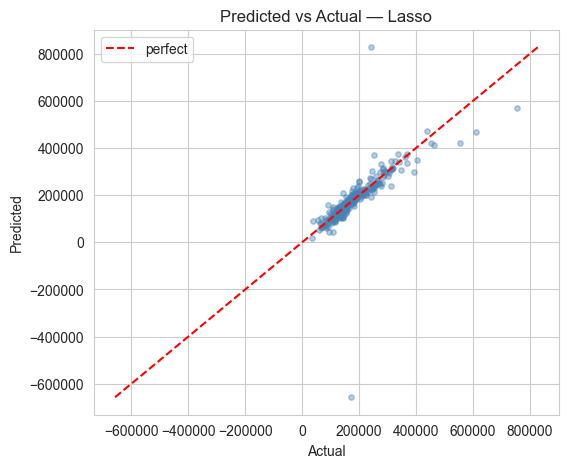

In [7]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 24766.1351
  RMSE  : 38695.9728
  R2    : 0.8048
  MAPE  : 0.1447


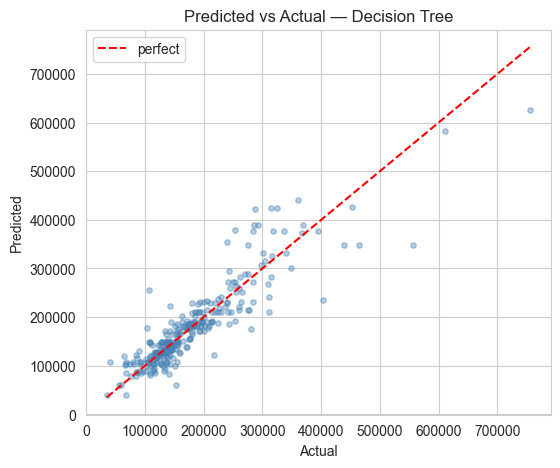

In [8]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 17753.7381
  RMSE  : 29630.6388
  R2    : 0.8855
  MAPE  : 0.1066


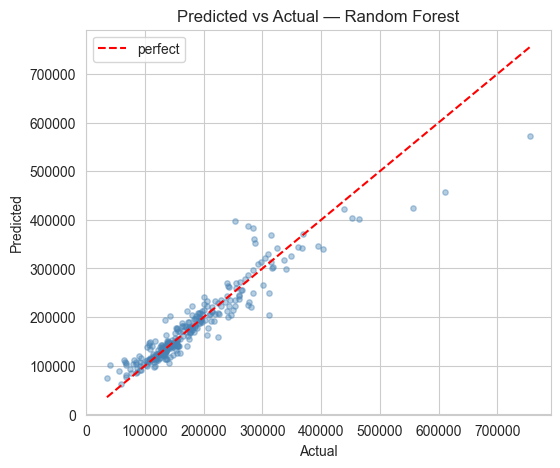

In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

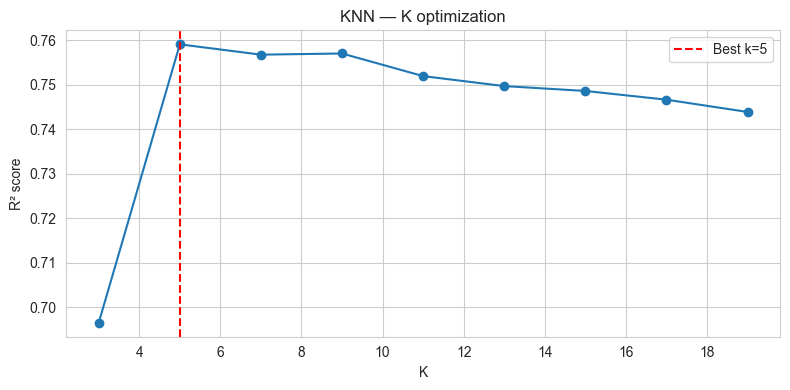


  KNN (k=5)
  MAE   : 24804.0199
  RMSE  : 42989.9066
  R2    : 0.7591
  MAPE  : 0.1537


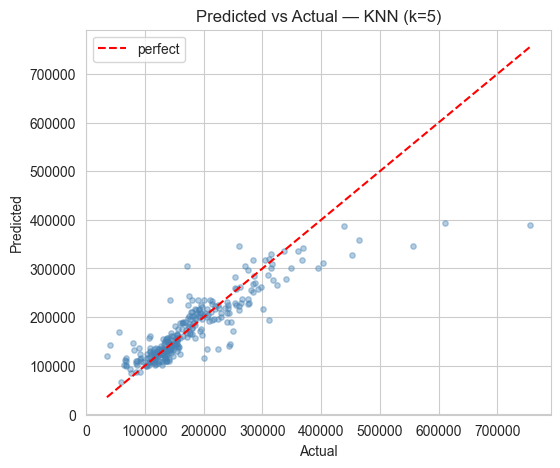

In [10]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 16122.2171
  RMSE  : 26547.6527
  R2    : 0.9081
  MAPE  : 0.0964


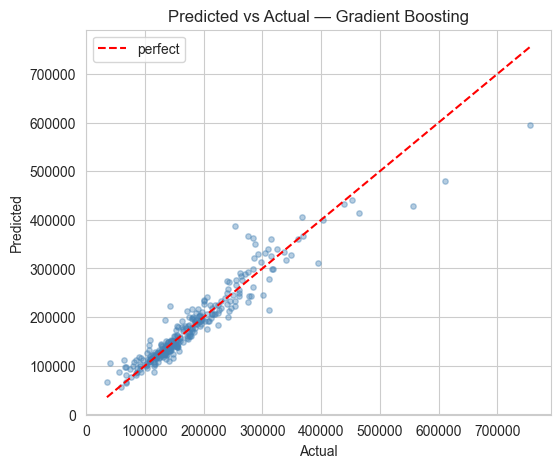

In [11]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

## 4. Feature Importance — Tree Models

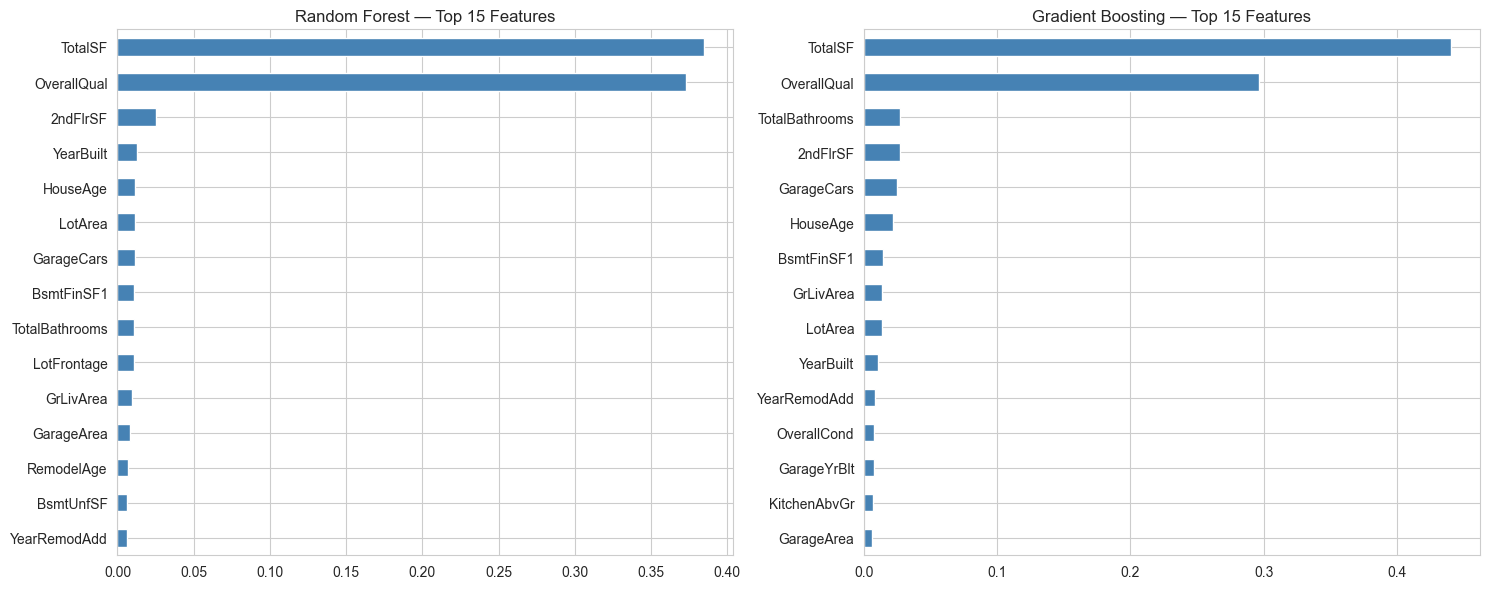

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

## 5. Model Comparison

In [13]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Gradient Boosting,1.612222e+04,2.654765e+04,9.081163e-01,9.637176e-02
1,Random Forest,1.775374e+04,2.963064e+04,8.855362e-01,1.065593e-01
2,Ridge,1.958849e+04,3.580737e+04,8.328405e-01,1.191380e-01
3,Decision Tree,2.476614e+04,3.869597e+04,8.047830e-01,1.446832e-01
4,KNN (k=5),2.480402e+04,4.298991e+04,7.590543e-01,1.537388e-01
5,Lasso,2.233633e+04,6.548000e+04,4.410108e-01,1.326578e-01
6,Linear Regression,8.763642e+14,1.027386e+16,-1.376111e+22,4.764416e+09


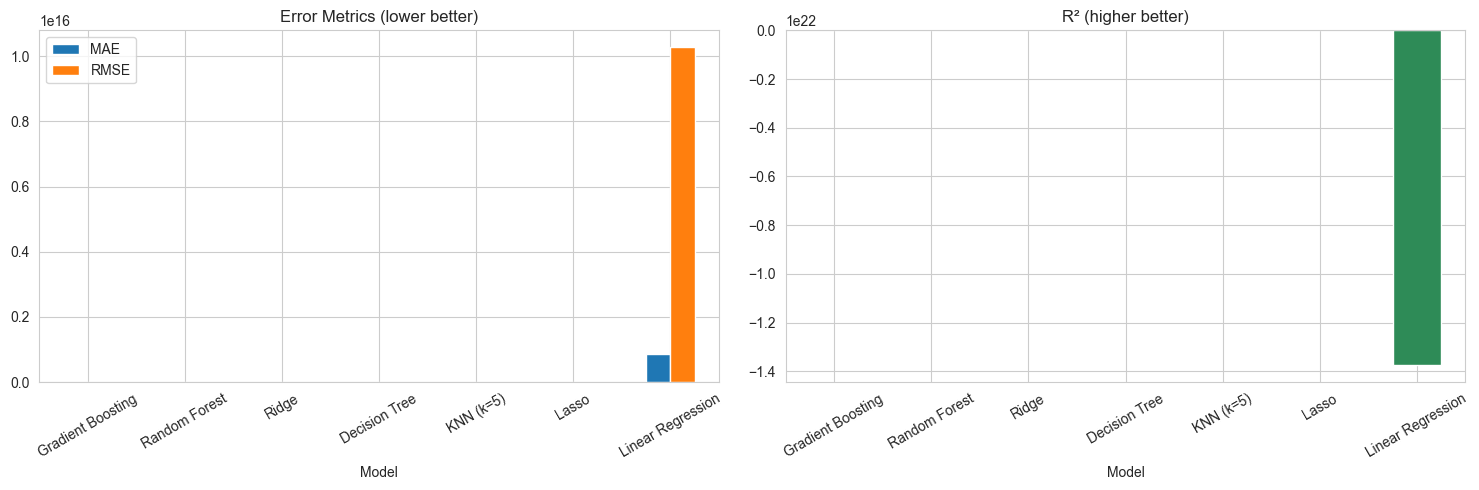

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [15]:
cv_scores = {}
X_full_scaled = scaler.fit_transform(X)
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = -36439349887978859428577280.0000 (+/- 26175334786911427102769152.0000)


Ridge                     mean R² = 0.7183 (+/- 0.1771)


/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.520e+10, tolerance: 6.990e+08
  model = cd_fast.enet_coordinate_descent(


/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.391e+10, tolerance: 7.288e+08
  model = cd_fast.enet_coordinate_descent(
/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.028e+10, tolerance: 7.249e+08
  model = cd_fast.enet_coordinate_descent(
/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.808e+10, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(


Lasso                     mean R² = 0.6783 (+/- 0.2400)


Decision Tree             mean R² = 0.7348 (+/- 0.0515)


Random Forest             mean R² = 0.8613 (+/- 0.0301)


KNN (k=5)                 mean R² = 0.7466 (+/- 0.0546)


Gradient Boosting         mean R² = 0.8985 (+/- 0.0241)


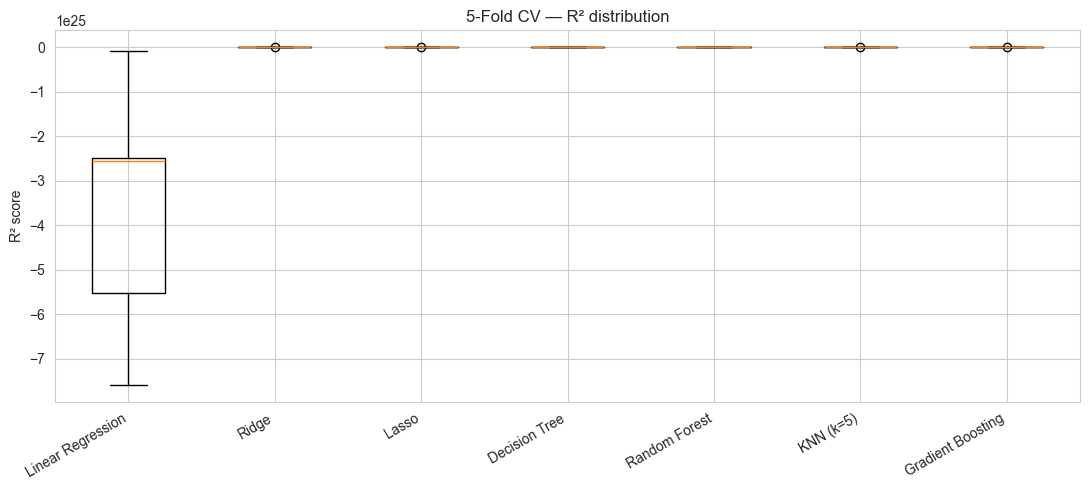

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

## 7. Residuals — Best Model

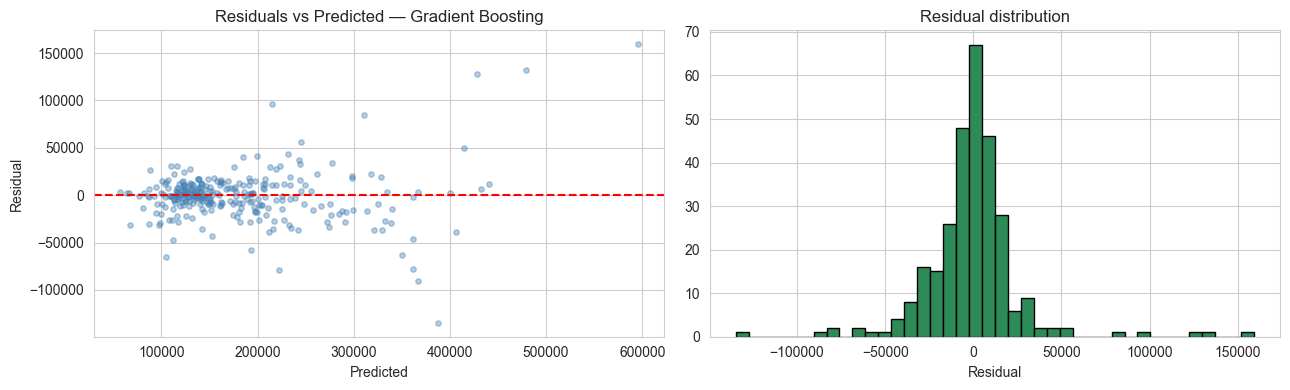

In [17]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

## 8. Hyperparameter Tuning — Best Performer

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
Best CV R²: 0.8804

  Gradient Boosting (Tuned)
  MAE   : 16096.2626
  RMSE  : 27124.3409
  R2    : 0.9041
  MAPE  : 0.0977


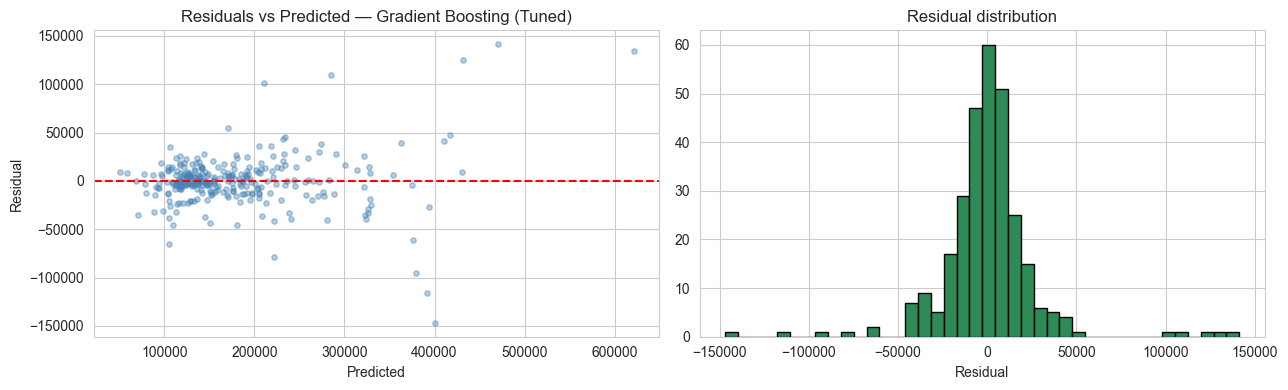

In [18]:
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
}
gb_tuned = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gb_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Gradient Boosting (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Gradient Boosting (Tuned)'); plt.show()

## 9. Tuned Model — Feature Importance

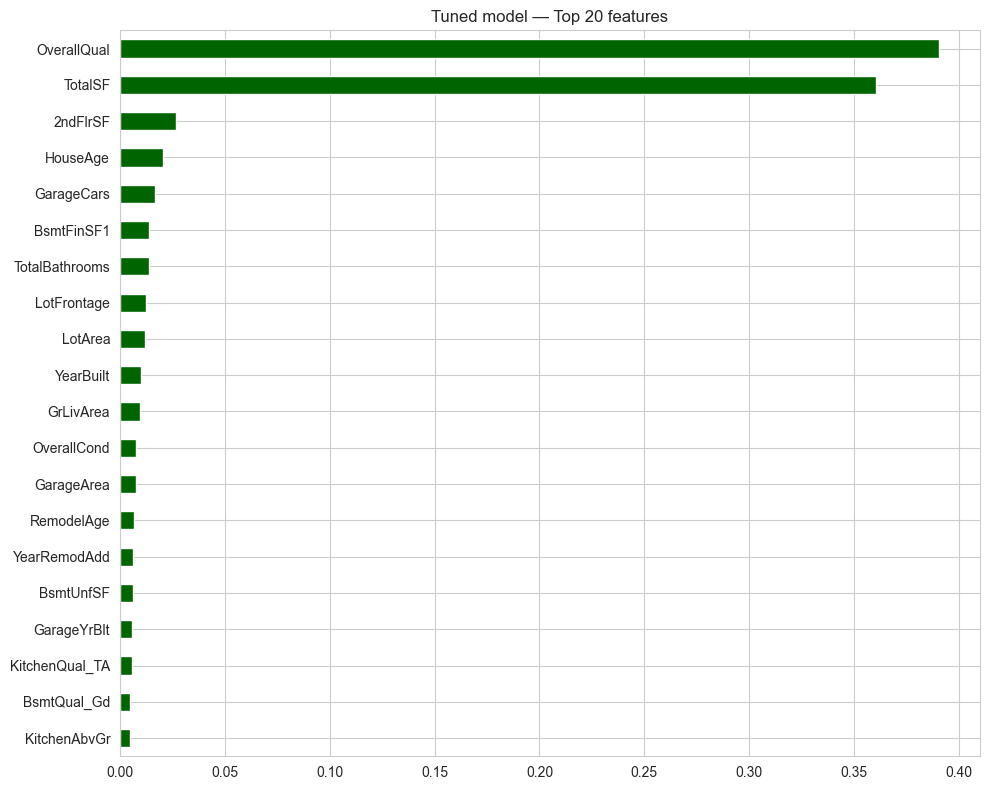

In [19]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

## 10. Sample Prediction

In [20]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,135558.81,154500,18941.19
1,313633.75,325000,11366.25
2,104647.71,115000,10352.29
3,154866.21,159000,4133.79
4,322154.92,315500,6654.92


## 11. Final Summary

In [21]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Gradient Boosting,1.612222e+04,2.654765e+04,9.081163e-01,9.637176e-02
1,Gradient Boosting (Tuned),1.609626e+04,2.712434e+04,9.040810e-01,9.770834e-02
2,Random Forest,1.775374e+04,2.963064e+04,8.855362e-01,1.065593e-01
3,Ridge,1.958849e+04,3.580737e+04,8.328405e-01,1.191380e-01
4,Decision Tree,2.476614e+04,3.869597e+04,8.047830e-01,1.446832e-01
5,KNN (k=5),2.480402e+04,4.298991e+04,7.590543e-01,1.537388e-01
6,Lasso,2.233633e+04,6.548000e+04,4.410108e-01,1.326578e-01
7,Linear Regression,8.763642e+14,1.027386e+16,-1.376111e+22,4.764416e+09


### Key Takeaways

- House Price Prediction: regression on `SalePrice`.
- 7 regressors + 1 tuned variant evaluated on MAE / RMSE / R² / MAPE.
- Tree-based models highlight the most predictive features.
- Predicted-vs-actual scatter plots reveal where models systematically over/underestimate.

### Next Steps

- Try gradient boosters (XGBoost, LightGBM) for further gains.
- Apply log-transform on skewed targets and re-fit.
- Add domain-specific feature engineering.